In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1) Load the given dataset

In [2]:
cd C:\Users\rjban\Desktop\ml\ML Projects

C:\Users\rjban\Desktop\ml\ML Projects


In [3]:
df = pd.read_csv("ML Project - Linear Regression Insurance Prediction.txt")

In [4]:
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [6]:
df.shape

(1338, 7)

# 2) Fill Null value of children column with the value 0

In [8]:
df["children"] = df["children"].fillna(0)

# 3) Replace the Null values of the column BMI with mean value

In [10]:
 df["bmi"] =df["bmi"].fillna(df["bmi"].mean())

# 4) Display a scatter plot between age and children

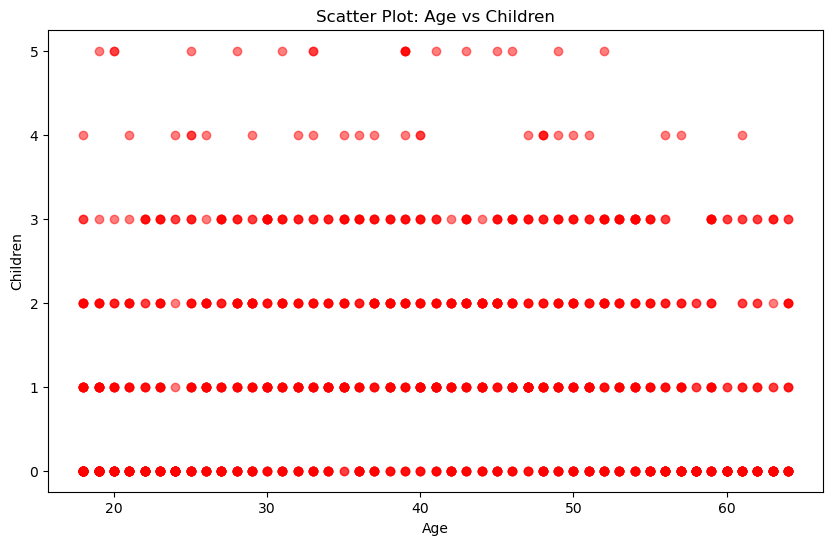

In [14]:
plt.figure(figsize=(10,6))
plt.scatter(df["age"], df["children"], color="red", alpha=0.5)
plt.title("Scatter Plot: Age vs Children")
plt.xlabel("Age")
plt.ylabel("Children")
plt.show()

# 5) Display bar plot between BMI and children

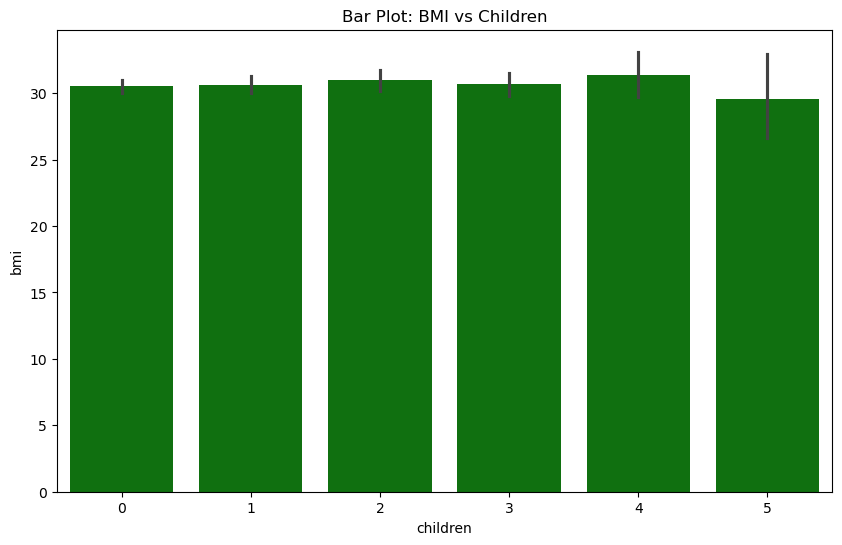

In [17]:
plt.figure(figsize=(10,6))
sns.barplot(x="children", y="bmi",color="green", data=df)
plt.title("Bar Plot: BMI vs Children")
plt.show()

# 6) Perform encoding to convert character data into numerical data

In [25]:
le=LabelEncoder()

In [26]:
categorical_cols=["sex","smoker","region"]

In [28]:
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [29]:
df[col]

0       3
1       2
2       2
3       1
4       1
       ..
1333    1
1334    0
1335    2
1336    3
1337    1
Name: region, Length: 1338, dtype: int64

# 7) Perform scaling

In [30]:
scaler = StandardScaler()

In [31]:
features_to_scale = ["age", "bmi", "children", "sex", "smoker", "region"]
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [32]:
df[features_to_scale]

,age,bmi,children,sex,smoker,region
0,-1.438764,-0.453320,-0.908614,-1.010519,1.970587,1.343905
1,-1.509965,0.509621,-0.078767,0.989591,-0.507463,0.438495
2,-0.797954,0.383307,1.580926,0.989591,-0.507463,0.438495
3,-0.441948,-1.305531,-0.908614,0.989591,-0.507463,-0.466915
4,-0.513149,-0.292556,-0.908614,0.989591,-0.507463,-0.466915
...,...,...,...,...,...,...
1333,0.768473,0.050297,1.580926,0.989591,-0.507463,-0.466915
1334,-1.509965,0.206139,-0.908614,-1.010519,-0.507463,-1.372326
1335,-1.509965,1.014878,-0.908614,-1.010519,-0.507463,0.438495
1336,-1.296362,-0.797813,-0.908614,-1.010519,-0.507463,1.343905


# Part-2: Working with Models

# 1) Separate feature data from target data 

In [33]:
x = df.drop("charges", axis=1)
y = df["charges"]

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 2) Create a Linear regression model between Features and target data

In [36]:
model = LinearRegression()

In [41]:
model.fit(x_train, y_train)

LinearRegression()

# 3) Display the test score and training score

In [38]:
model.score(x_train, y_train)

0.7417049283233981

In [39]:
model.score(x_test, y_test)

0.7833463107364536

In [40]:
yp=model.predict(x_test)

# 4) Extract slope and intercept value from the model

In [42]:
model.coef_

array([ 3.61028043e+03, -9.39521400e+00,  2.04689296e+03,  5.12253132e+02,
        9.54291505e+03, -2.99625864e+02])

In [43]:
model.intercept_

np.float64(13315.445192139769)

# 5) Display Mean Squared Error

In [47]:
metrics.mean_squared_error(y_test, yp)

33635210.43117845

# 6) Display Mean Absolute Error

In [48]:
metrics.mean_absolute_error(y_test, yp)

4186.508898366437

# 7) Display Root mean Squared error

In [49]:
np.sqrt(metrics.mean_squared_error(y_test, yp))

np.float64(5799.5870914383595)

# 8) Display R2 score

In [51]:
metrics.r2_score(y_test, yp)

0.7833463107364536